In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  OrdinalEncoder, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix


# Load Dataset into pandas dataframe
Upload the Dataset in the environment to continue

In [57]:
df=pd.read_csv('/content/Thyroid_Diff.csv')

# Explorarotory data analysis

In [9]:
df.shape

(383, 17)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

In [11]:
categorical_columns = df.select_dtypes(include=['object']).columns

for column in categorical_columns:
  unique_values = df[column].unique()
  print(f"Unique values for {column}: {unique_values}")

Unique values for Gender: ['F' 'M']
Unique values for Smoking: ['No' 'Yes']
Unique values for Hx Smoking: ['No' 'Yes']
Unique values for Hx Radiothreapy: ['No' 'Yes']
Unique values for Thyroid Function: ['Euthyroid' 'Clinical Hyperthyroidism' 'Clinical Hypothyroidism'
 'Subclinical Hyperthyroidism' 'Subclinical Hypothyroidism']
Unique values for Physical Examination: ['Single nodular goiter-left' 'Multinodular goiter'
 'Single nodular goiter-right' 'Normal' 'Diffuse goiter']
Unique values for Adenopathy: ['No' 'Right' 'Extensive' 'Left' 'Bilateral' 'Posterior']
Unique values for Pathology: ['Micropapillary' 'Papillary' 'Follicular' 'Hurthel cell']
Unique values for Focality: ['Uni-Focal' 'Multi-Focal']
Unique values for Risk: ['Low' 'Intermediate' 'High']
Unique values for T: ['T1a' 'T1b' 'T2' 'T3a' 'T3b' 'T4a' 'T4b']
Unique values for N: ['N0' 'N1b' 'N1a']
Unique values for M: ['M0' 'M1']
Unique values for Stage: ['I' 'II' 'IVB' 'III' 'IVA']
Unique values for Response: ['Indeterminate

1. Gender
Gender
F    312
M     71
Name: count, dtype: int64


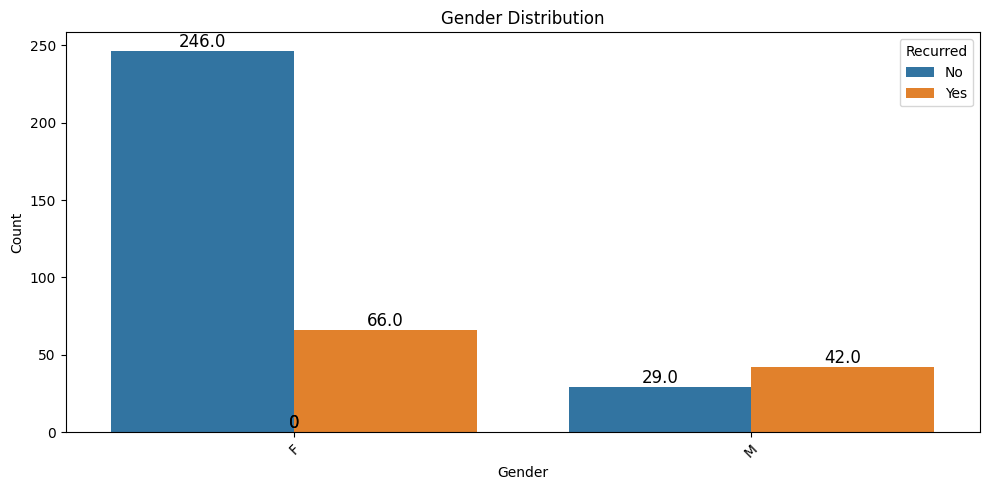

2. Smoking
Smoking
No     334
Yes     49
Name: count, dtype: int64


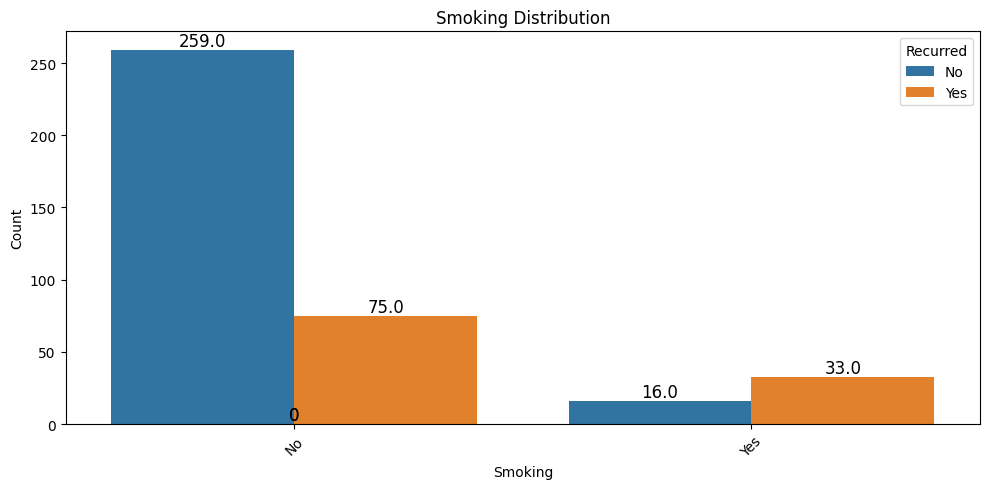

3. Hx Smoking
Hx Smoking
No     355
Yes     28
Name: count, dtype: int64


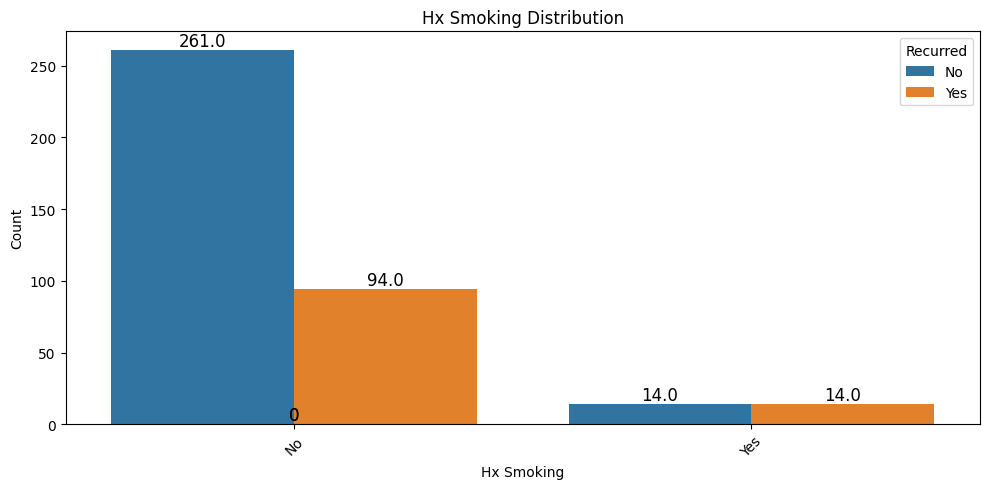

4. Hx Radiothreapy
Hx Radiothreapy
No     376
Yes      7
Name: count, dtype: int64


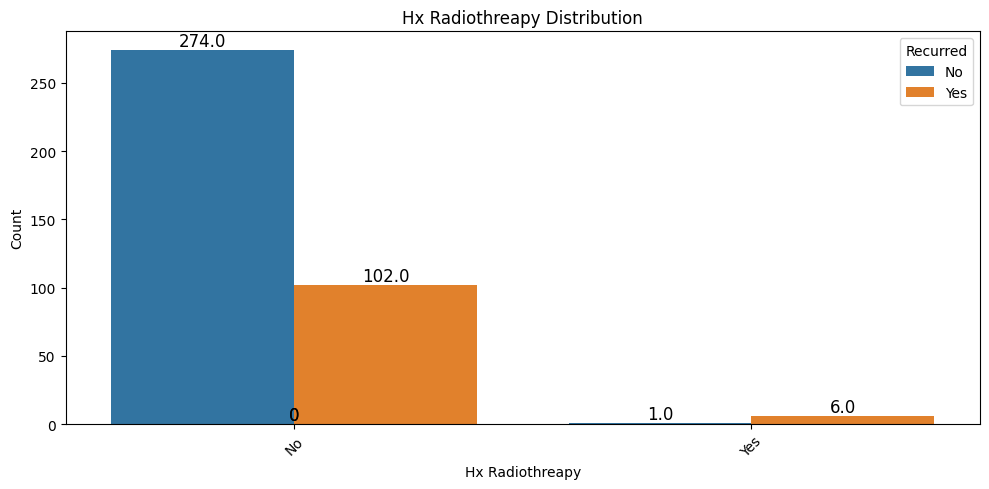

5. Thyroid Function
Thyroid Function
Euthyroid                      332
Clinical Hyperthyroidism        20
Subclinical Hypothyroidism      14
Clinical Hypothyroidism         12
Subclinical Hyperthyroidism      5
Name: count, dtype: int64


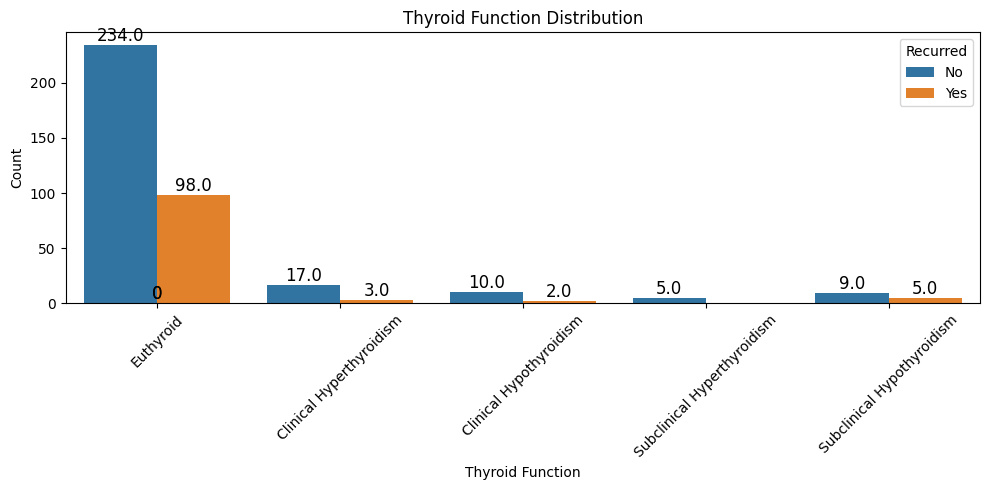

6. Physical Examination
Physical Examination
Multinodular goiter            140
Single nodular goiter-right    140
Single nodular goiter-left      89
Normal                           7
Diffuse goiter                   7
Name: count, dtype: int64


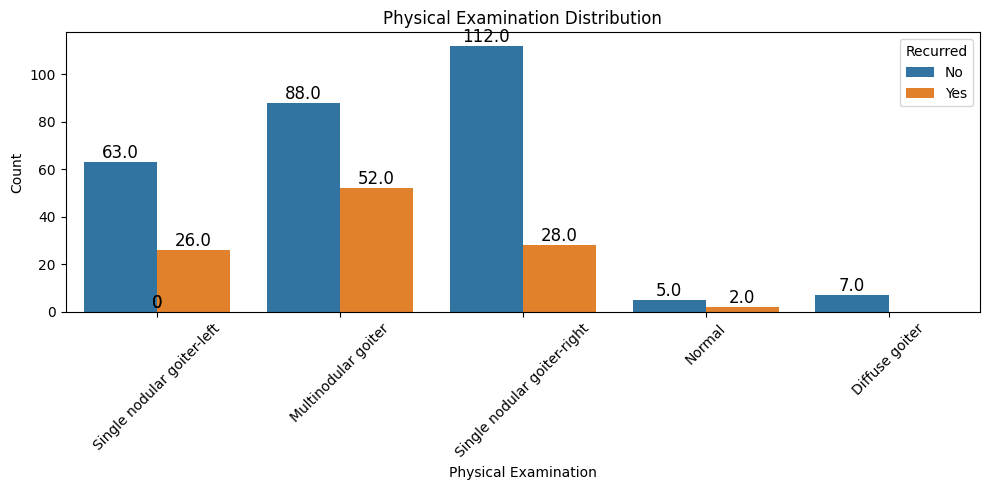

7. Adenopathy
Adenopathy
No           277
Right         48
Bilateral     32
Left          17
Extensive      7
Posterior      2
Name: count, dtype: int64


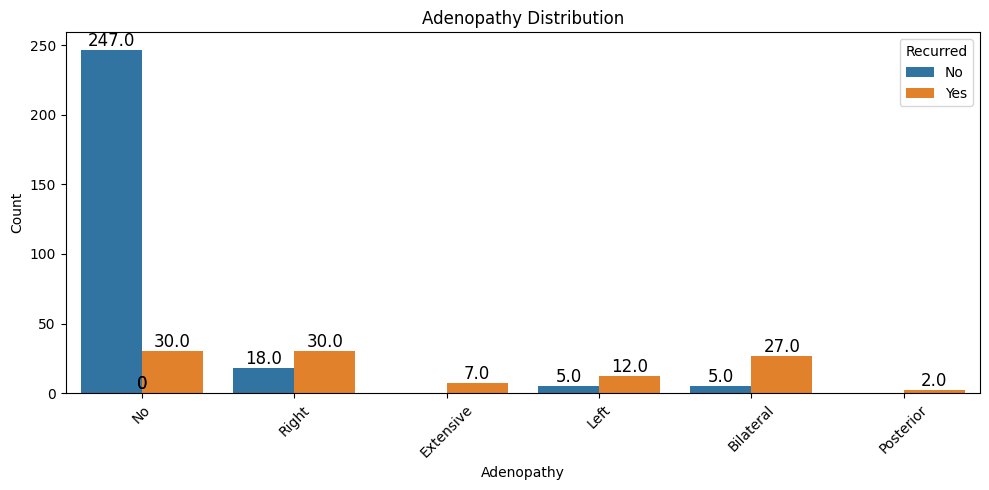

8. Pathology
Pathology
Papillary         287
Micropapillary     48
Follicular         28
Hurthel cell       20
Name: count, dtype: int64


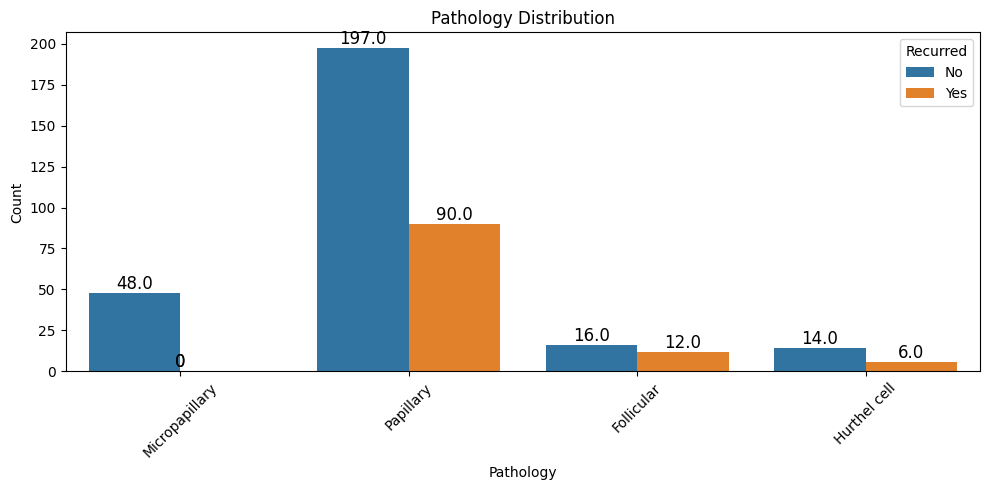

9. Focality
Focality
Uni-Focal      247
Multi-Focal    136
Name: count, dtype: int64


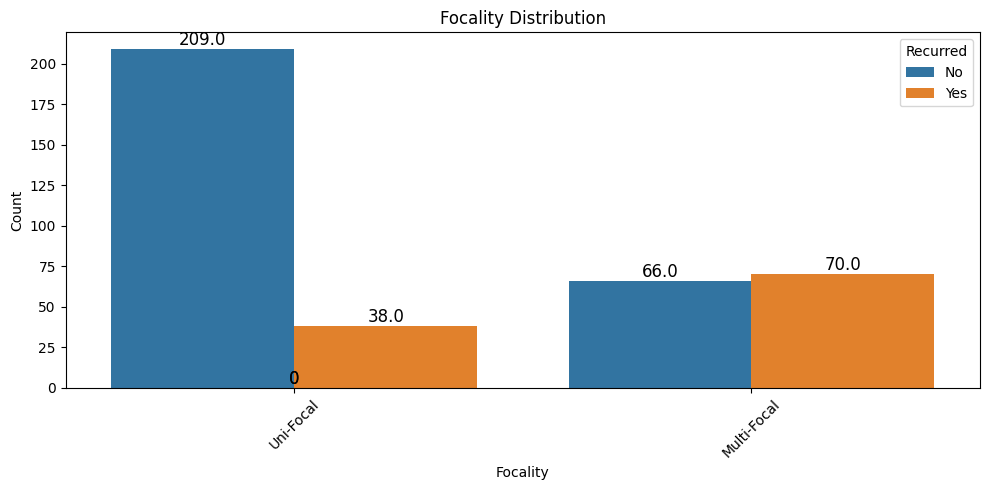

10. Risk
Risk
Low             249
Intermediate    102
High             32
Name: count, dtype: int64


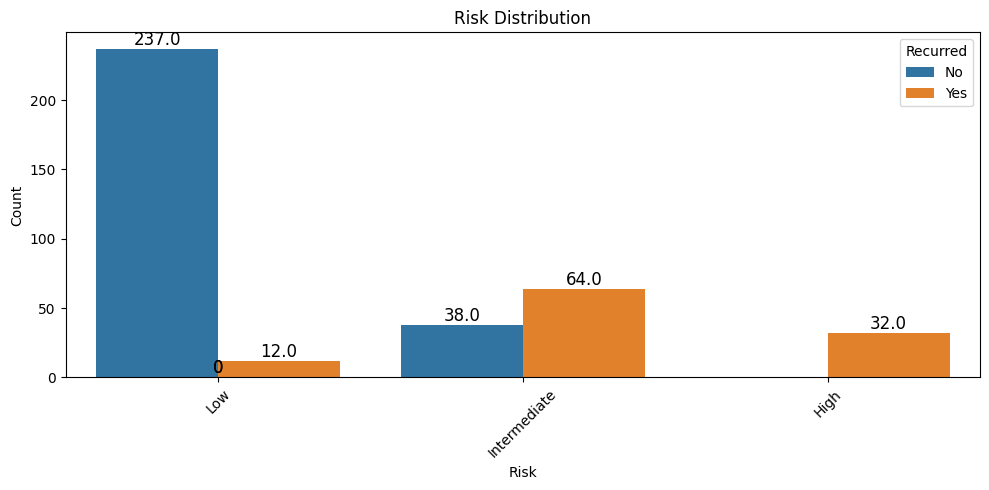

11. T
T
T2     151
T3a     96
T1a     49
T1b     43
T4a     20
T3b     16
T4b      8
Name: count, dtype: int64


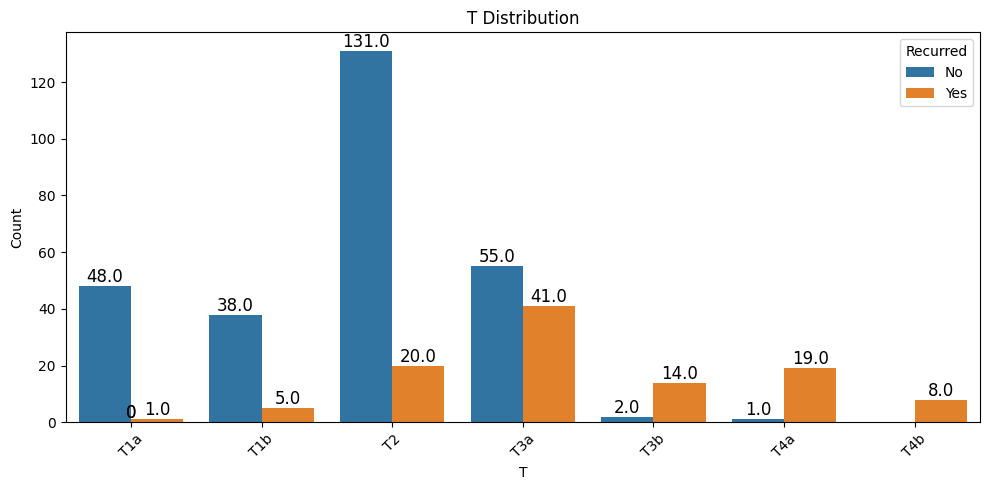

12. N
N
N0     268
N1b     93
N1a     22
Name: count, dtype: int64


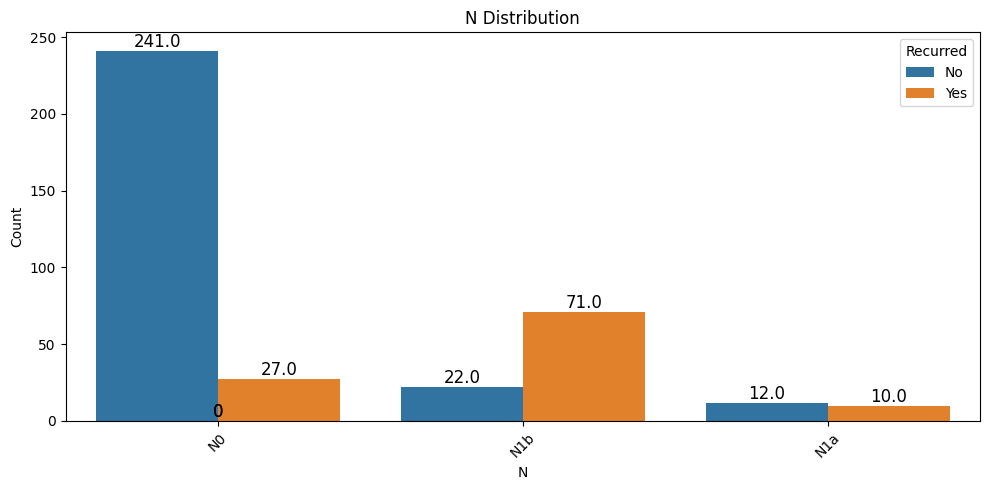

13. M
M
M0    365
M1     18
Name: count, dtype: int64


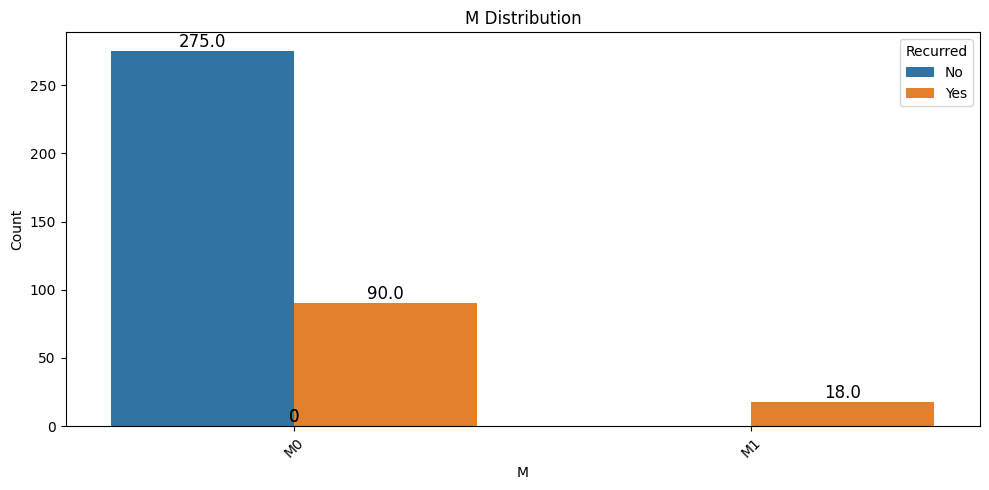

14. Stage
Stage
I      333
II      32
IVB     11
III      4
IVA      3
Name: count, dtype: int64


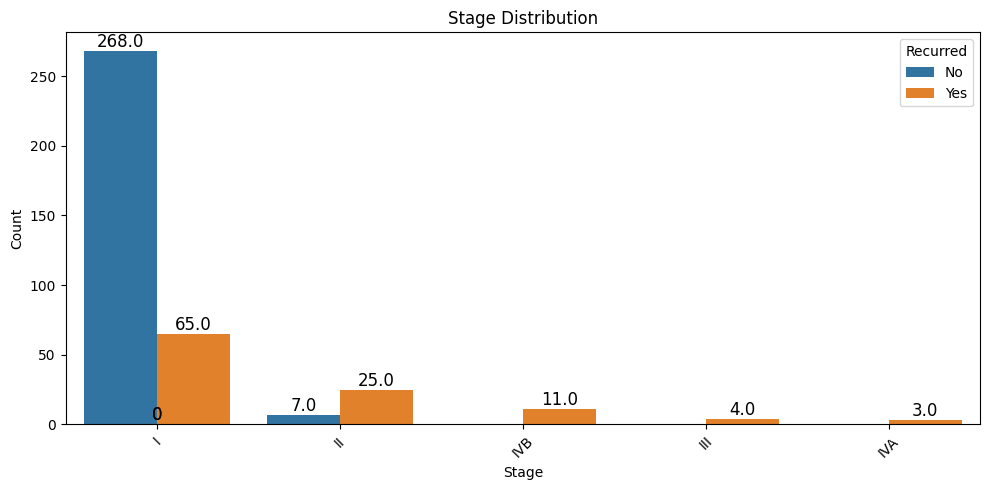

15. Response
Response
Excellent                 208
Structural Incomplete      91
Indeterminate              61
Biochemical Incomplete     23
Name: count, dtype: int64


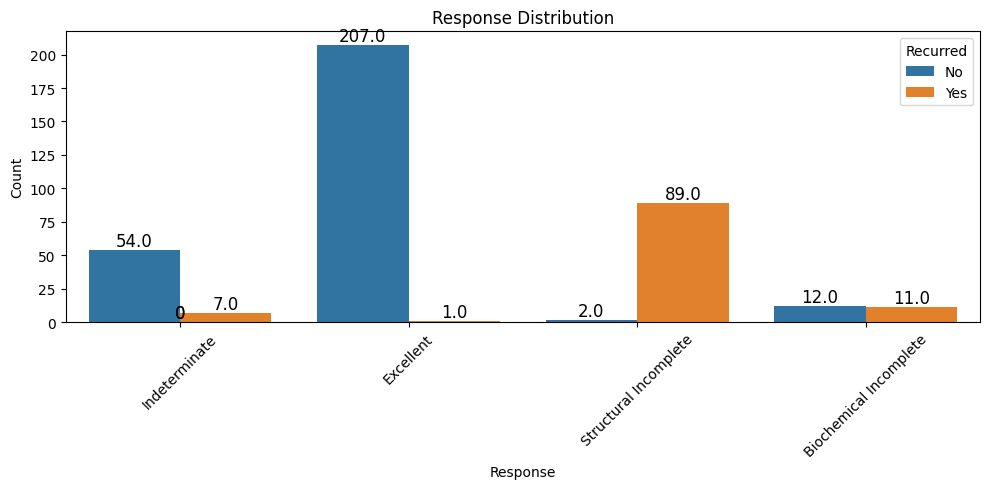

16. Recurred
Recurred
No     275
Yes    108
Name: count, dtype: int64


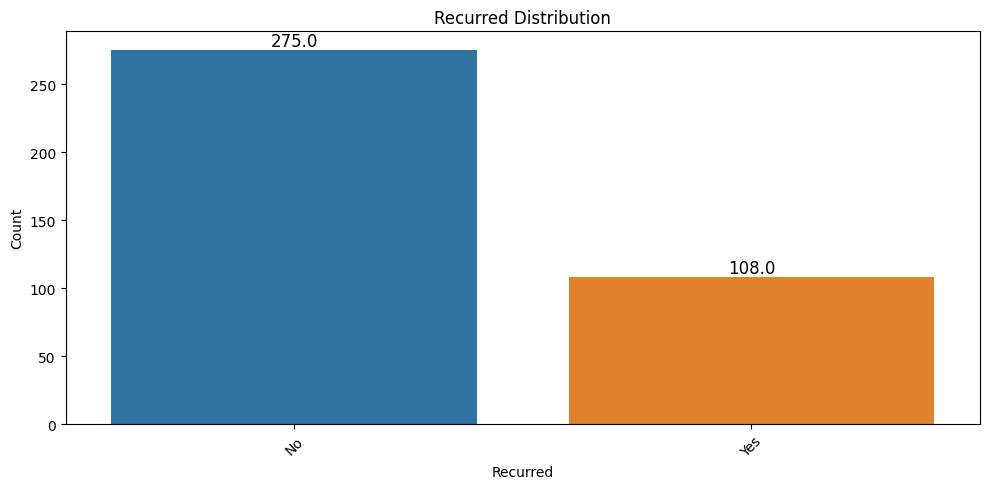

In [13]:
i = 0
for column in df.select_dtypes(include='object').columns:
    i += 1
    print(f"{i}. {column}\n{df[column].value_counts()}")
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(x=column, hue='Recurred', data=df)
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=12, color='black')
    plt.title(f'{column} Distribution')
    plt.xlabel(column)
    plt.ylabel('Count')
    plt.xticks(rotation=45)  # Rotate x-axis labels by 45 degrees
    plt.tight_layout()  # Adjust layout to fit labels
    plt.show()

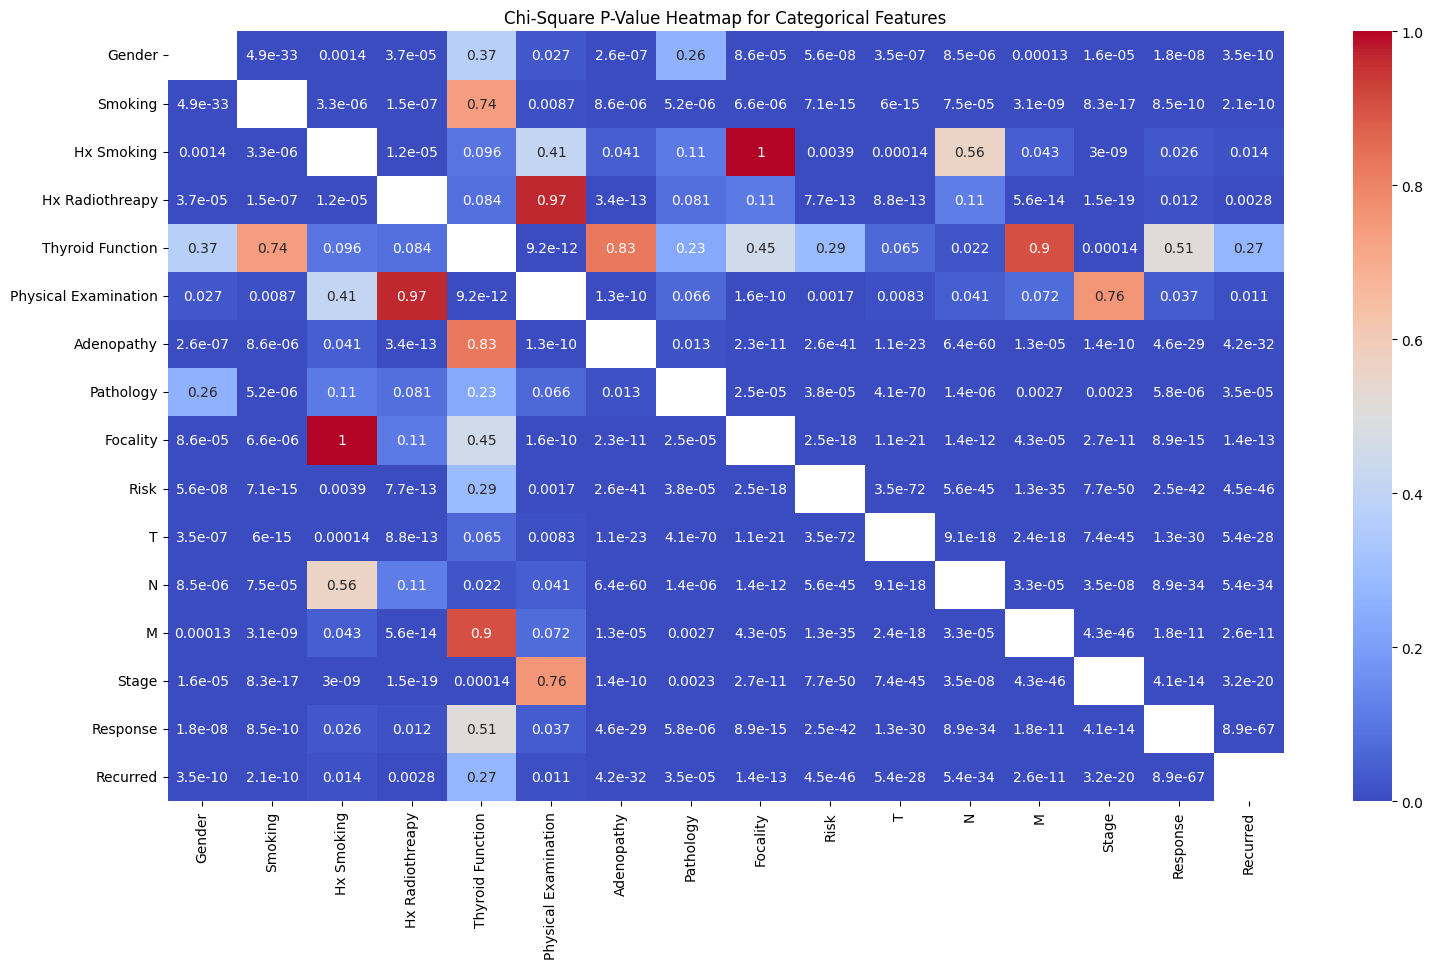

In [12]:
categorical_features = df.select_dtypes(include=['object']).columns
p_value_matrix = np.zeros((len(categorical_features), len(categorical_features)))

for i, feature1 in enumerate(categorical_features):
    for j, feature2 in enumerate(categorical_features):
        if i != j:
            contingency_table = pd.crosstab(df[feature1], df[feature2])
            _, p, _, _ = chi2_contingency(contingency_table)
            p_value_matrix[i, j] = p
        else:
            p_value_matrix[i, j] = np.nan


plt.figure(figsize=(18, 10))
sns.heatmap(p_value_matrix, annot=True, cmap='coolwarm', xticklabels=categorical_features, yticklabels=categorical_features)
plt.title('Chi-Square P-Value Heatmap for Categorical Features')
plt.show()


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

Ordinal Encoding

In [15]:
mapping = {
    'Risk': ['Low', 'Intermediate', 'High'],
    'T': ['T1a', 'T1b', 'T2', 'T3a','T3b', 'T4a','T4b'],
    'N': ['N0', 'N1a', 'N1b'],
    'M': ['M0', 'M1'],
    'Stage': ['I', 'II', 'III', 'IVA','IVB'],

}

enc = OrdinalEncoder(categories=[mapping['Risk'], mapping['T'], mapping['N'], mapping['M'], mapping['Stage']],
                    handle_unknown='use_encoded_value', unknown_value=np.nan)


df[['Risk', 'T', 'N', 'M', 'Stage']] = enc.fit_transform(df[['Risk', 'T', 'N', 'M', 'Stage']])

Label Encoding

In [16]:
label_encoder = LabelEncoder()
for column in df.columns:
  if df[column].dtype == object and column not in ['Risk', 'T', 'N', 'M', 'Stage']:
    df[column] = label_encoder.fit_transform(df[column])


In [17]:
print(df)

     Age  Gender  Smoking  Hx Smoking  Hx Radiothreapy  Thyroid Function  \
0     27       0        0           0                0                 2   
1     34       0        0           1                0                 2   
2     30       0        0           0                0                 2   
3     62       0        0           0                0                 2   
4     62       0        0           0                0                 2   
..   ...     ...      ...         ...              ...               ...   
378   72       1        1           1                1                 2   
379   81       1        1           0                1                 2   
380   72       1        1           1                0                 2   
381   61       1        1           1                1                 0   
382   67       1        1           0                0                 2   

     Physical Examination  Adenopathy  Pathology  Focality  Risk    T    N  \
0        

In [18]:
df.head()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,0,0,0,0,2,3,3,2,1,0.0,0.0,0.0,0.0,0.0,2,0
1,34,0,0,1,0,2,1,3,2,1,0.0,0.0,0.0,0.0,0.0,1,0
2,30,0,0,0,0,2,4,3,2,1,0.0,0.0,0.0,0.0,0.0,1,0
3,62,0,0,0,0,2,4,3,2,1,0.0,0.0,0.0,0.0,0.0,1,0
4,62,0,0,0,0,2,1,3,2,0,0.0,0.0,0.0,0.0,0.0,1,0


In [19]:
df.tail()

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,1,1,1,1,2,4,5,3,1,2.0,6.0,2.0,1.0,4.0,0,1
379,81,1,1,0,1,2,1,1,3,0,2.0,6.0,2.0,1.0,4.0,3,1
380,72,1,1,1,0,2,1,0,3,0,2.0,6.0,2.0,1.0,4.0,3,1
381,61,1,1,1,1,0,1,1,1,0,2.0,6.0,2.0,0.0,3.0,3,1
382,67,1,1,0,0,2,1,0,3,0,2.0,6.0,2.0,0.0,3.0,3,1


Normalization

In [20]:
scaler = MinMaxScaler()

df['Age'] = scaler.fit_transform(df[['Age']])

print(df)

          Age  Gender  Smoking  Hx Smoking  Hx Radiothreapy  Thyroid Function  \
0    0.179104       0        0           0                0                 2   
1    0.283582       0        0           1                0                 2   
2    0.223881       0        0           0                0                 2   
3    0.701493       0        0           0                0                 2   
4    0.701493       0        0           0                0                 2   
..        ...     ...      ...         ...              ...               ...   
378  0.850746       1        1           1                1                 2   
379  0.985075       1        1           0                1                 2   
380  0.850746       1        1           1                0                 2   
381  0.686567       1        1           1                1                 0   
382  0.776119       1        1           0                0                 2   

     Physical Examination  

In [21]:
x=df.drop('Recurred',axis=1)
y=df['Recurred']

In [22]:
print(x)

          Age  Gender  Smoking  Hx Smoking  Hx Radiothreapy  Thyroid Function  \
0    0.179104       0        0           0                0                 2   
1    0.283582       0        0           1                0                 2   
2    0.223881       0        0           0                0                 2   
3    0.701493       0        0           0                0                 2   
4    0.701493       0        0           0                0                 2   
..        ...     ...      ...         ...              ...               ...   
378  0.850746       1        1           1                1                 2   
379  0.985075       1        1           0                1                 2   
380  0.850746       1        1           1                0                 2   
381  0.686567       1        1           1                1                 0   
382  0.776119       1        1           0                0                 2   

     Physical Examination  

In [ ]:
print(y)

0      0
1      0
2      0
3      0
4      0
      ..
378    1
379    1
380    1
381    1
382    1
Name: Recurred, Length: 383, dtype: int64


# Dataset Split

In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(306, 16)
(77, 16)
(306,)
(77,)


# MODEL TRAINING

# Logistic Regression

In [25]:
param_grid_lr ={
        'C': [0.01, 0.03,0.09,0.1, 1],
        'solver': ['liblinear', 'saga']
    }

In [26]:
lr=LogisticRegression(random_state=42)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(x_train,y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which 

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42),
             param_grid={'C': [0.01, 0.03, 0.09, 0.1, 1],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [27]:
print("Best parameter for Logistic Regression: ",grid_lr.best_params_)

Best parameter for Logistic Regression:  {'C': 0.03, 'solver': 'saga'}


In [28]:
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(x_test)
test_score = best_lr.score(x_test, y_test)
print("Average Cross-Validation Accuracy For Logistic Regression on Training Data:", grid_lr.best_score_)
print("Testing Accuracy For Logistic Regression: ",test_score)

Average Cross-Validation Accuracy For Logistic Regression on Training Data: 0.9019566367001586
Testing Accuracy For Logistic Regression:  0.9090909090909091


In [29]:
print("Precision For Logistic Regression:", precision_score(y_test, y_pred_lr))
print("Recall For Logistic Regression:", recall_score(y_test, y_pred_lr))
print("F1-Score For Logistic Regression:", f1_score(y_test, y_pred_lr))

Precision For Logistic Regression: 0.9285714285714286
Recall For Logistic Regression: 0.6842105263157895
F1-Score For Logistic Regression: 0.7878787878787878


# *Support* Vector Classifier

In [30]:
param_grid_svc={

        'C': [0.01, 0.03,0.09,0.1, 1],
        'kernel': ['linear', 'rbf']
    }
svc= SVC(random_state=42)
grid_svc = GridSearchCV(svc, param_grid_svc, cv=5, scoring='accuracy')
grid_svc.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=SVC(random_state=42),
             param_grid={'C': [0.01, 0.03, 0.09, 0.1, 1],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [31]:
print("Best parameter for Support Vector Classifier",grid_svc.best_params_)

Best parameter for Support Vector Classifier {'C': 0.01, 'kernel': 'linear'}


In [32]:
best_svc = grid_svc.best_estimator_
y_pred_svc = best_svc.predict(x_test)
test_score = best_svc.score(x_test, y_test)
print("Average Cross-Validation Accuracy For Support Vector Classifier on Training Data:", grid_svc.best_score_)
print("Testing Accuracy For Support Vector Classifier:", test_score)

Average Cross-Validation Accuracy For Support Vector Classifier on Training Data: 0.905288207297726
Testing Accuracy For Support Vector Classifier: 0.9090909090909091


In [33]:
print("Precision For Support Vector Classifier:", precision_score(y_test, y_pred_svc))
print("Recall For Support Vector Classifier:", recall_score(y_test, y_pred_svc))
print("F1-Score For Support Vector Classifier:", f1_score(y_test, y_pred_svc))

Precision For Support Vector Classifier: 0.9285714285714286
Recall For Support Vector Classifier: 0.6842105263157895
F1-Score For Support Vector Classifier: 0.7878787878787878


# Random Forest Classifier

In [34]:
param_grid_rf = {
    'n_estimators': [10,15,20,50,100],
    'criterion': ['gini', 'entropy','log_loss'],

    'max_depth': [None,10,20,30],
    'min_samples_split': [2, 4,6,8],
    'min_samples_leaf': [1, 2,3],
    'max_features': ['auto', 'sqrt', 'log2']
}
random_forest = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(random_forest, param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
3600 fits failed out of a total of 10800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3600 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.10/dist-packages/sklearn/

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [None, 10, 20, 30],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 4, 6, 8],
                         'n_estimators': [10, 15, 20, 50, 100]},
             scoring='accuracy')

In [35]:
print("Best parameter for Random Forest Classifier",grid_rf.best_params_)

Best parameter for Random Forest Classifier {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 15}


In [36]:
best_rf=grid_rf.best_estimator_
y_pred_rf = best_rf.predict(x_test)
test_score = best_rf.score(x_test, y_test)
print("Average Cross-Validation Accuracy For Random Forest Classifier on Training Data:", grid_rf.best_score_)
print("Testing Accuracy For Random Forest Classifier:", test_score)

Average Cross-Validation Accuracy For Random Forest Classifier on Training Data: 0.9608143839238499
Testing Accuracy For Random Forest Classifier: 0.987012987012987


In [37]:
print("Precision For Random Forest Classifier:", precision_score(y_test, y_pred_rf))
print("Recall For Random Forest Classifier:", recall_score(y_test, y_pred_rf))
print("F1-Score For Random Forest Classifier:", f1_score(y_test, y_pred_rf))

Precision For Random Forest Classifier: 1.0
Recall For Random Forest Classifier: 0.9473684210526315
F1-Score For Random Forest Classifier: 0.972972972972973


# AdaBoost Classifier

In [38]:
 param_grid_ab = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}
adaboost = AdaBoostClassifier(random_state=42)
grid_ab = GridSearchCV(adaboost, param_grid_ab, cv=5, scoring='accuracy')
grid_ab.fit(x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.1

GridSearchCV(cv=5, estimator=AdaBoostClassifier(random_state=42),
             param_grid={'learning_rate': [0.01, 0.1, 0.5, 1.0],
                         'n_estimators': [50, 100, 200, 300]},
             scoring='accuracy')

In [39]:
print("Best parameter for AdaBosst Classifier: ",grid_ab.best_params_)

Best parameter for AdaBosst Classifier:  {'learning_rate': 0.1, 'n_estimators': 50}


In [40]:
best_ab = grid_ab.best_estimator_
y_pred_ab = best_ab.predict(x_test)
test_score = best_ab.score(x_test, y_test)
print("Average Cross-Validation Accuracy For AdaBoost Classifier on Training Data:", grid_ab.best_score_)
print("Testing Accuracy For AdaBoost Classifier", test_score)


Average Cross-Validation Accuracy For AdaBoost Classifier on Training Data: 0.9542570068746695
Testing Accuracy For AdaBoost Classifier 0.961038961038961


In [41]:
print("Precision for AdaBoost Classifier:", precision_score(y_test, y_pred_ab))
print("Recall for AdaBoost Classifier:", recall_score(y_test, y_pred_ab))
print("F1-Score for AdaBoost Classifier:", f1_score(y_test, y_pred_ab))

Precision for AdaBoost Classifier: 1.0
Recall for AdaBoost Classifier: 0.8421052631578947
F1-Score for AdaBoost Classifier: 0.9142857142857143


# Gradient Boosting Classifier

In [42]:
param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01,0.03,0.09, 0.1,0.3],
    'max_depth': [3, 4,5],
    'subsample': [0.8,0.9,1.0]
}
gradient_boosting = GradientBoostingClassifier(random_state=42)
grid_gb = GridSearchCV(gradient_boosting, param_grid_gb, cv=5, scoring='accuracy')
grid_gb.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             param_grid={'learning_rate': [0.01, 0.03, 0.09, 0.1, 0.3],
                         'max_depth': [3, 4, 5], 'n_estimators': [100, 200],
                         'subsample': [0.8, 0.9, 1.0]},
             scoring='accuracy')

In [43]:
print("Best parameter for Gradient Boosting Classifier: ",grid_gb.best_params_)

Best parameter for Gradient Boosting Classifier:  {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [44]:
best_gb = grid_gb.best_estimator_
y_pred_gb = best_gb.predict(x_test)
test_score = best_gb.score(x_test, y_test)
print("Average Cross-Validation Accuracy For Gradient Boosting Classifier on Training Data:", grid_gb.best_score_)
print("Testing Accuracy For Gradient Boosting Classifier:", test_score)


Average Cross-Validation Accuracy For Gradient Boosting Classifier on Training Data: 0.9509783183500794
Testing Accuracy For Gradient Boosting Classifier: 0.974025974025974


In [45]:
print("Precision for Gradient Boosting Classifier:", precision_score(y_test, y_pred_gb))
print("Recall for Gradient Boosting Classifier:", recall_score(y_test, y_pred_gb))
print("F1-Score for Gradient Boosting Classifier:", f1_score(y_test, y_pred_gb))

Precision for Gradient Boosting Classifier: 0.9473684210526315
Recall for Gradient Boosting Classifier: 0.9473684210526315
F1-Score for Gradient Boosting Classifier: 0.9473684210526315


# XGBoost Classifier

In [46]:
param_grid_xgb = {
    'n_estimators': [50,60,70,80,100],
    'learning_rate': [0.01,0.03,0.09, 0.1,0.3],
    'max_depth': [2,3,4,5,6],
    'colsample_bytree': [0.6,0.7,0.8]
}
xgboost = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
grid_xgb = GridSearchCV(xgboost, param_grid_xgb, cv=5, scoring='accuracy')
grid_xgb.fit(x_train, y_train)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:22:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:22:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:22:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:22:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [16:22:26] WARNING: /worksp

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             param_grid={'colsample_bytree': [0.6, 0.7, 0.8],
                         'learning_rate': [0.01, 0.03, 0.09, 0.1, 0.3],
                         'max_depth': [2, 3, 4, 5, 6],
                         'n_estimators': [50, 60, 70, 80, 100]},
             scoring='accuracy')

In [47]:
print("Best parameter For XGBoost Classifier:",grid_xgb.best_params_)

Best parameter For XGBoost Classifier: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 50}


In [48]:
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(x_test)
test_score = best_xgb.score(x_test, y_test)
print("Average Cross-Validation Accuracy For XGBoost Classifier on Training Data:", grid_xgb.best_score_)
print("Testing Accuracy For XGBoost Classifier:", test_score)

Average Cross-Validation Accuracy For XGBoost Classifier on Training Data: 0.9575356953992596
Testing Accuracy For XGBoost Classifier: 0.974025974025974


In [49]:
print("Precision for XGBoost Classifier:", precision_score(y_test, y_pred_xgb))
print("Recall for XGBoost Classifier:", recall_score(y_test, y_pred_xgb))
print("F1-Score for XGBoost Classifier:", f1_score(y_test, y_pred_xgb))

Precision for XGBoost Classifier: 0.9473684210526315
Recall for XGBoost Classifier: 0.9473684210526315
F1-Score for XGBoost Classifier: 0.9473684210526315


# Model Evaluation

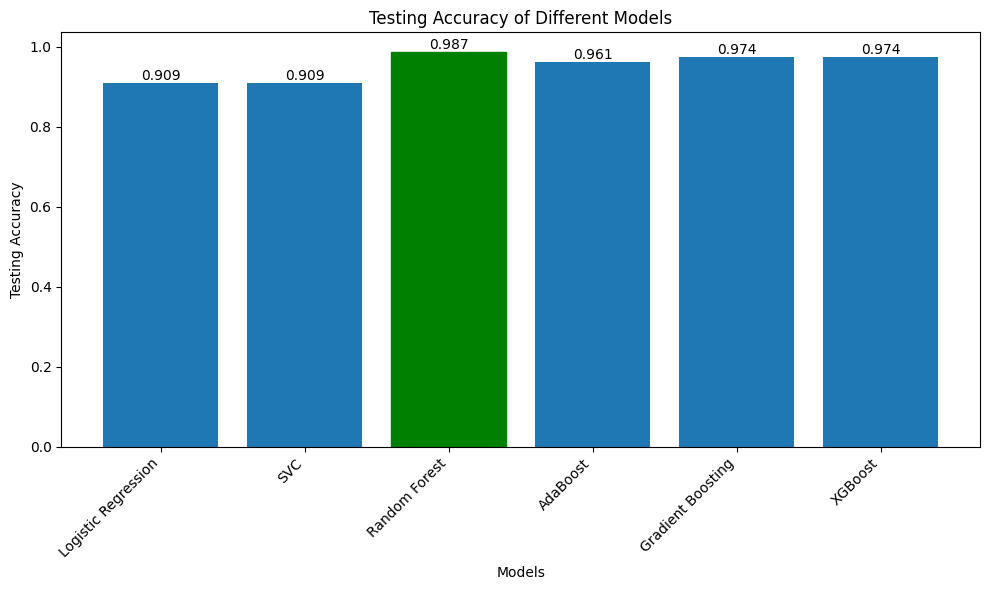

In [51]:
testing_accuracies = {
    'Logistic Regression': accuracy_score(y_test, y_pred_lr),
        'SVC': accuracy_score(y_test, y_pred_svc),
    'Random Forest': accuracy_score(y_test, y_pred_rf),
    'AdaBoost': accuracy_score(y_test, y_pred_ab),
    'Gradient Boosting': accuracy_score(y_test, y_pred_gb),
    'XGBoost': accuracy_score(y_test, y_pred_xgb)



}
highest_accuracy = max(testing_accuracies.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(testing_accuracies.keys(), testing_accuracies.values())

for bar in bars:
  if bar.get_height() == highest_accuracy:
    bar.set_color('green')


for bar in bars:
  yval = bar.get_height()
  plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3), ha='center', va='bottom')

plt.xlabel('Models')
plt.ylabel('Testing Accuracy')
plt.title('Testing Accuracy of Different Models')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

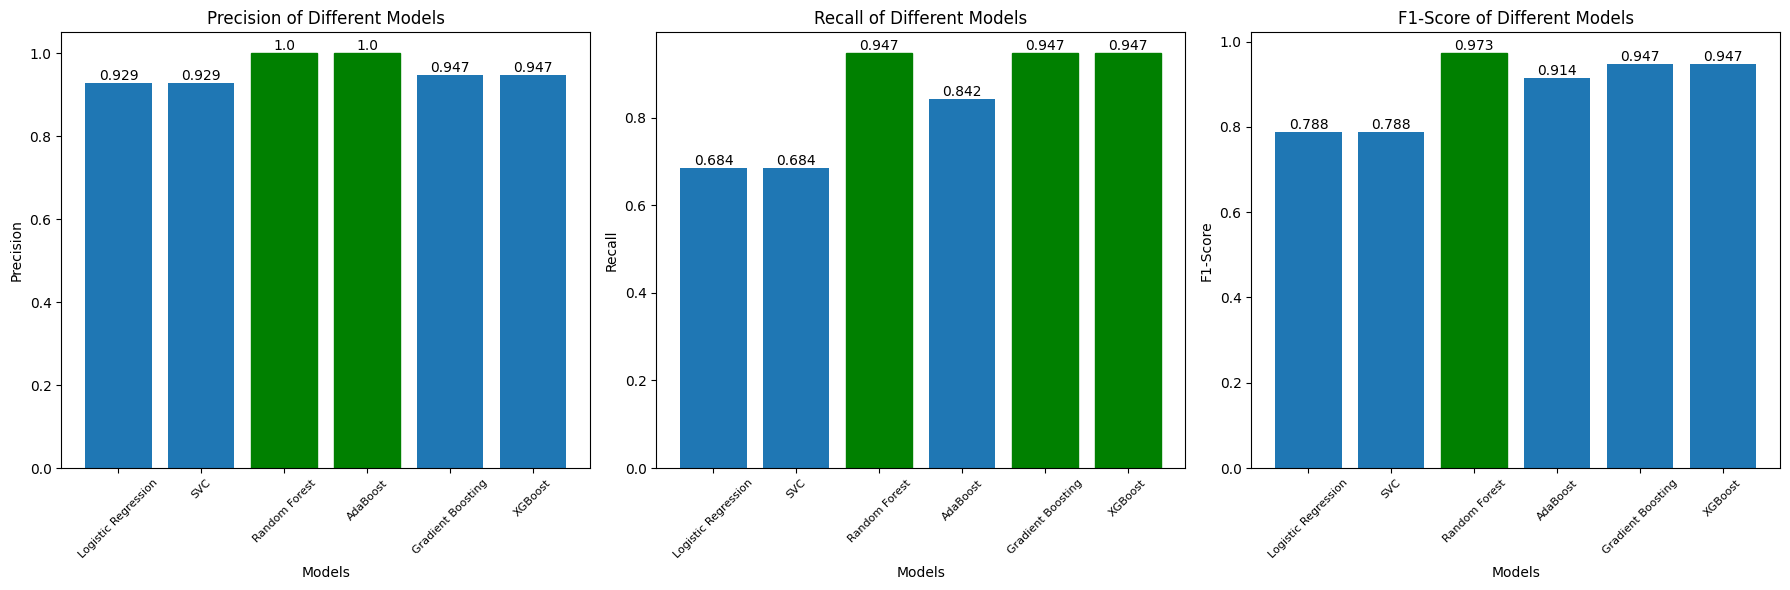

In [54]:

import matplotlib.pyplot as plt
model_metrics = {
    'Logistic Regression': {'Precision': precision_score(y_test, y_pred_lr),
                            'Recall': recall_score(y_test, y_pred_lr),
                            'F1-Score': f1_score(y_test, y_pred_lr)},
    'SVC': {'Precision': precision_score(y_test, y_pred_svc),
            'Recall': recall_score(y_test, y_pred_svc),
            'F1-Score': f1_score(y_test, y_pred_svc)},
    'Random Forest': {'Precision': precision_score(y_test, y_pred_rf),
                      'Recall': recall_score(y_test, y_pred_rf),
                      'F1-Score': f1_score(y_test, y_pred_rf)},
    'AdaBoost': {'Precision': precision_score(y_test, y_pred_ab),
                 'Recall': recall_score(y_test, y_pred_ab),
                 'F1-Score': f1_score(y_test, y_pred_ab)},
    'Gradient Boosting': {'Precision': precision_score(y_test, y_pred_gb),
                          'Recall': recall_score(y_test, y_pred_gb),
                          'F1-Score': f1_score(y_test, y_pred_gb)},
    'XGBoost': {'Precision': precision_score(y_test, y_pred_xgb),
                'Recall': recall_score(y_test, y_pred_xgb),
                'F1-Score': f1_score(y_test, y_pred_xgb)}
}

metrics = ['Precision', 'Recall', 'F1-Score']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, metric in enumerate(metrics):
  metric_scores = {model: scores[metric] for model, scores in model_metrics.items()}
  highest_metric = max(metric_scores.values())
  bars = axes[i].bar(metric_scores.keys(), metric_scores.values())
  for bar in bars:
      if bar.get_height() == highest_metric:
          bar.set_color('green')
  for bar in bars:
      yval = bar.get_height()
      axes[i].text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3), ha='center', va='bottom')
  axes[i].set_xlabel('Models')
  axes[i].set_ylabel(metric)
  axes[i].set_title(f'{metric} of Different Models')
  axes[i].tick_params(axis='x', rotation=45, labelsize=8)


plt.tight_layout()
plt.show()


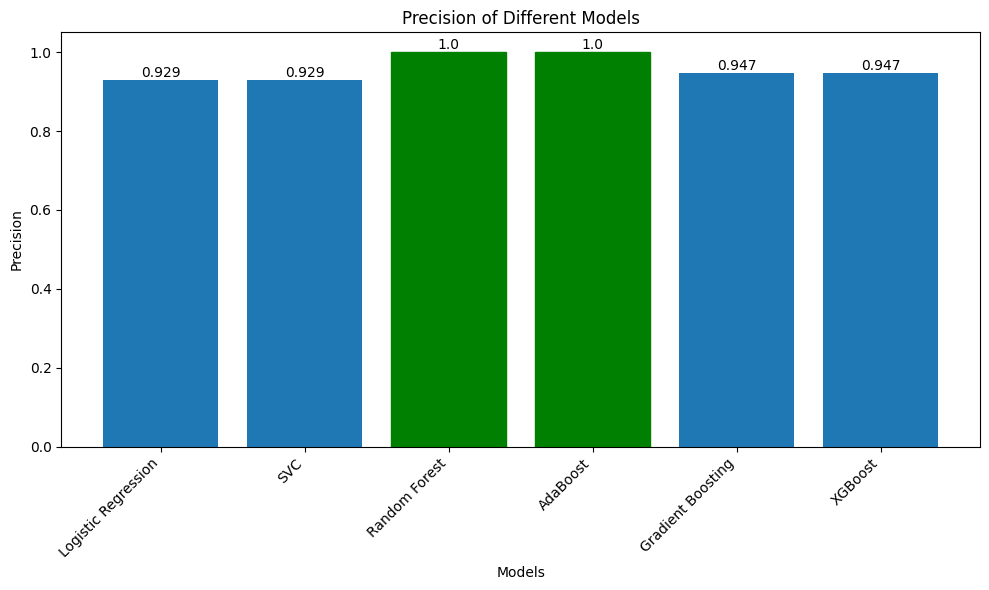

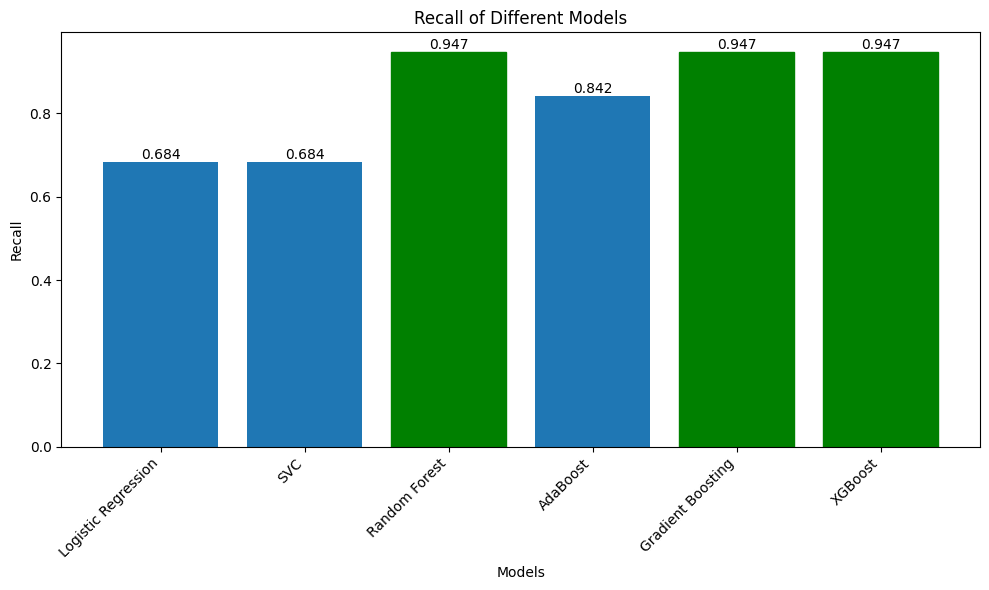

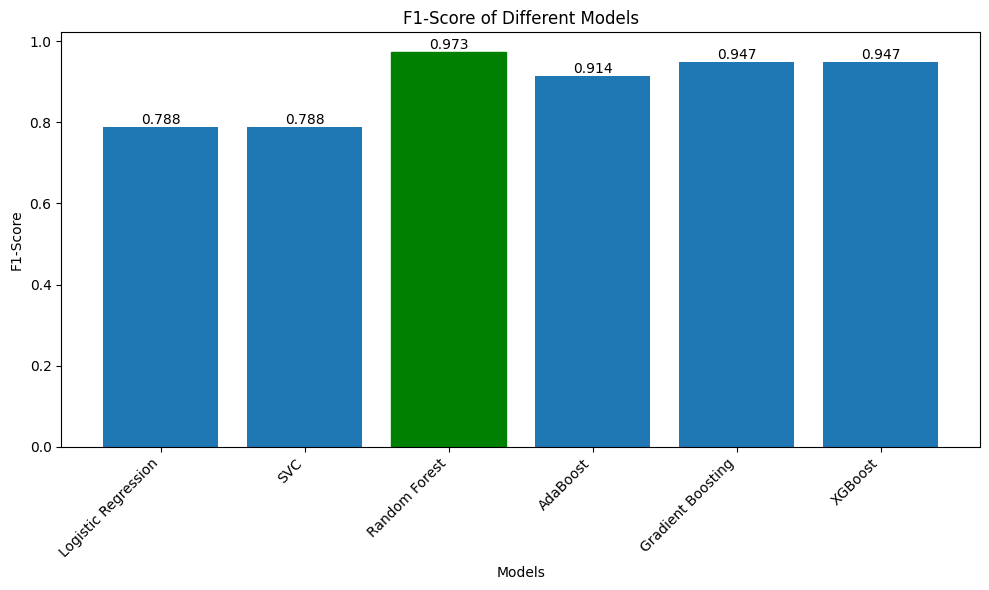

In [58]:

import matplotlib.pyplot as plt
model_metrics = {
    'Logistic Regression': {'Precision': precision_score(y_test, y_pred_lr),
                            'Recall': recall_score(y_test, y_pred_lr),
                            'F1-Score': f1_score(y_test, y_pred_lr)},
    'SVC': {'Precision': precision_score(y_test, y_pred_svc),
            'Recall': recall_score(y_test, y_pred_svc),
            'F1-Score': f1_score(y_test, y_pred_svc)},
    'Random Forest': {'Precision': precision_score(y_test, y_pred_rf),
                      'Recall': recall_score(y_test, y_pred_rf),
                      'F1-Score': f1_score(y_test, y_pred_rf)},
    'AdaBoost': {'Precision': precision_score(y_test, y_pred_ab),
                 'Recall': recall_score(y_test, y_pred_ab),
                 'F1-Score': f1_score(y_test, y_pred_ab)},
    'Gradient Boosting': {'Precision': precision_score(y_test, y_pred_gb),
                          'Recall': recall_score(y_test, y_pred_gb),
                          'F1-Score': f1_score(y_test, y_pred_gb)},
    'XGBoost': {'Precision': precision_score(y_test, y_pred_xgb),
                'Recall': recall_score(y_test, y_pred_xgb),
                'F1-Score': f1_score(y_test, y_pred_xgb)}
}

metrics = ['Precision', 'Recall', 'F1-Score']

for metric in metrics:
    metric_scores = {model: scores[metric] for model, scores in model_metrics.items()}
    highest_metric = max(metric_scores.values())

    plt.figure(figsize=(10, 6))
    bars = plt.bar(metric_scores.keys(), metric_scores.values())

    for bar in bars:
        if bar.get_height() == highest_metric:
            bar.set_color('green')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3), ha='center', va='bottom')

    plt.xlabel('Models')
    plt.ylabel(metric)
    plt.title(f'{metric} of Different Models')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


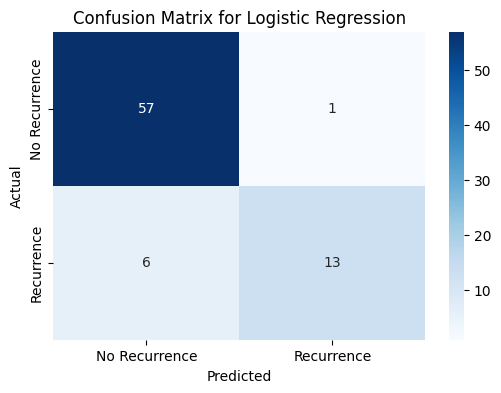

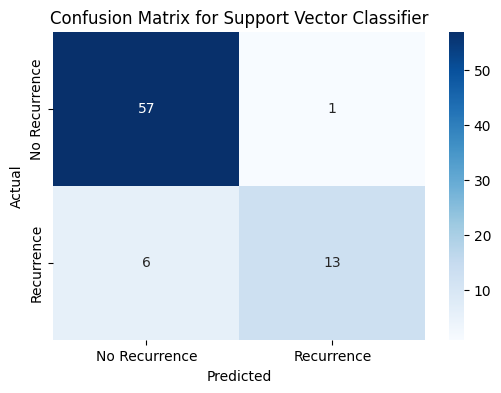

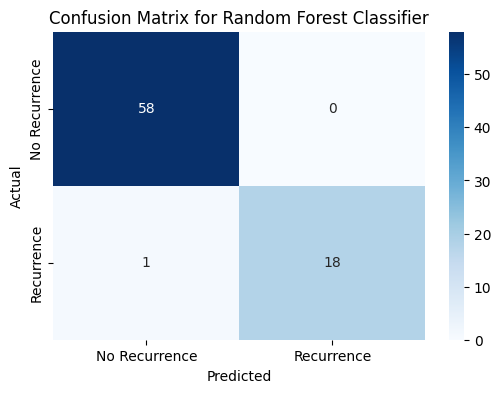

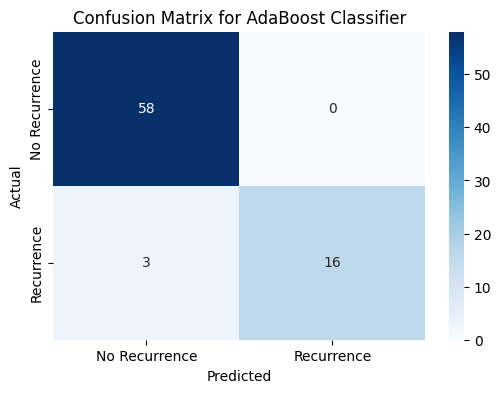

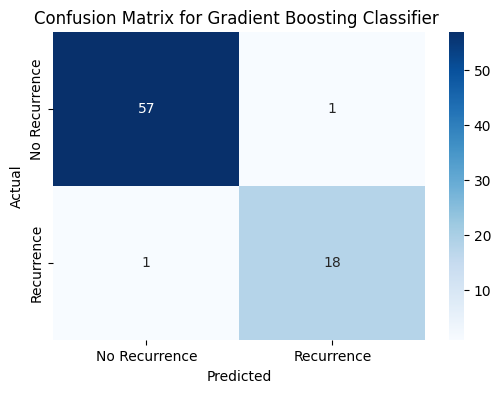

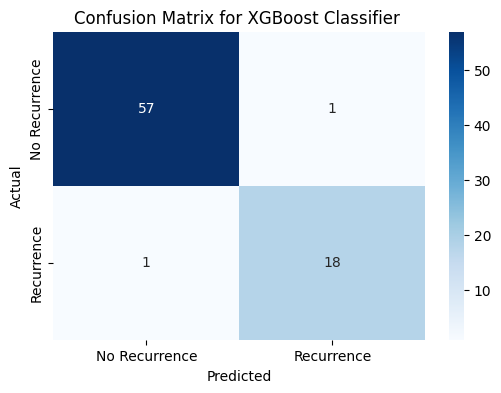

In [55]:
def plot_confusion_matrix(y_true, y_pred, title):
  cm = confusion_matrix(y_true, y_pred)
  plt.figure(figsize=(6, 4))
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
              xticklabels=['No Recurrence', 'Recurrence'],
              yticklabels=['No Recurrence', 'Recurrence'])
  plt.title(title)
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.show()

plot_confusion_matrix(y_test, y_pred_lr, "Confusion Matrix for Logistic Regression")
plot_confusion_matrix(y_test, y_pred_svc, "Confusion Matrix for Support Vector Classifier")
plot_confusion_matrix(y_test, y_pred_rf, "Confusion Matrix for Random Forest Classifier")
plot_confusion_matrix(y_test, y_pred_ab, "Confusion Matrix for AdaBoost Classifier")
plot_confusion_matrix(y_test, y_pred_gb, "Confusion Matrix for Gradient Boosting Classifier ")
plot_confusion_matrix(y_test, y_pred_xgb, "Confusion Matrix for XGBoost Classifier ")

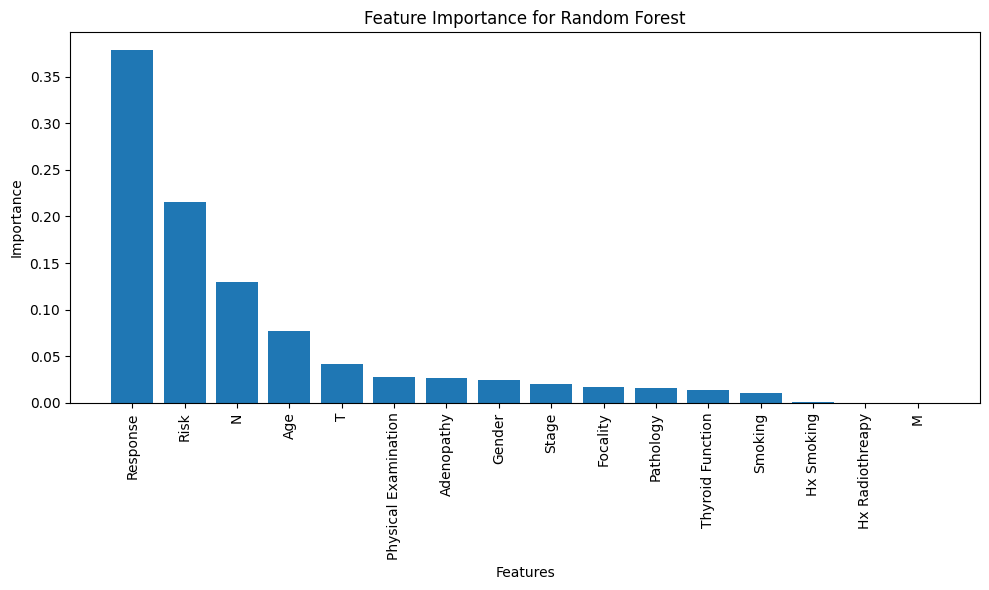

In [56]:
importances = best_rf.feature_importances_
feature_names = x.columns

feature_importances_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})


feature_importances_df = feature_importances_df.sort_values('Importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.bar(feature_importances_df['Feature'], feature_importances_df['Importance'])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance for Random Forest')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()